# 3D prostředí (jde se udělat half-life 3)

### Orientace ve 3D prostoru
V 3D prostoru používáme tři základní směry, kterým říkáme X, Y a Z:

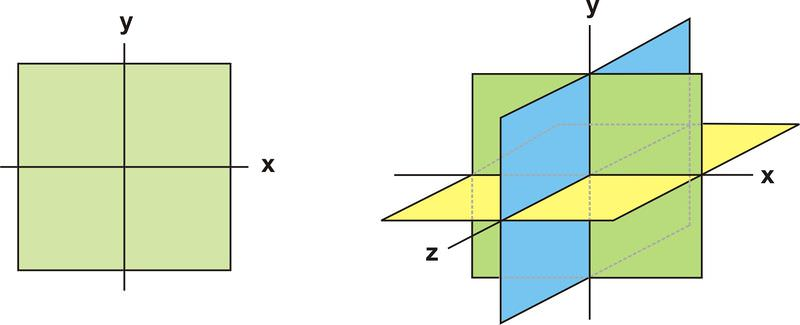

#### Pozice vs. Rotace vs. Měřítko
Každá věc v 3D prostoru má obvykle tyto  vlastnosti:

Position (Pozice): Kde věc je? Např. (0, 5, 10) znamená: ve středu, 5 metrů ve vzduchu a 10 metrů před námi.

Rotation (Rotace): Jak je věc otočená? Měříme ji ve stupních (0–360). Můžeš postavu otočit kolem dokola jako na kolotoči (rotation_y).

Scale (Měřítko): Jak je věc velká? Můžeš mít hubeňoura (0.5, 2, 0.5) nebo obra (5, 5, 5).

### Co je Ursina?

https://www.ursinaengine.org/documentation.html

Ursina je herní engine. Představte si ho jako **digitální stavebnici**. Každá věc ve hře (hráč, meč, monstrum) je tzv. **Entity** (Entita). Každá entita má:

* **Model**: Jaký má tvar (kostka, koule, placka).
* **Texture**: Jak vypadá její povrch (tráva, cihly).
* **Position**: Kde se ve světě nachází (osy X, Y, Z).
* **(Rotaci, Měřítko)**

---

# Stavba světa

Každý program v Ursině musí začít inicializací (`app = Ursina()`) a končit spuštěním (`app.run()`). Vše mezi tím je naše tvoření.

**Souřadnice ve 3D:**

* **X**: Doleva (-) a Doprava (+)
* **Y**: Dolů (-) a Nahoru (+)
* **Z**: Dozadu (-) a Dopředu (+)

---


In [ ]:
from ursina import *

app = Ursina()

# 1. Louka
podlaha = Entity(model='plane', texture='grass', scale=20)

# 2. Hrdina Freeman
freeman = Entity(
    model='cube', 
    color=color.gray, 
    scale=(1, 2, 1), 
    position=(0, 1, 0) # Stojí na podlaze
)

# 3. Kamera (pohled zezadu)
camera.position = (0, 7, -15)
camera.rotation_x = 25

app.run()

#### Znázornění os, entit atd.:

In [ ]:
from ursina import *

# Reset pro Jupyter
if 'app' in locals():
    del app
app = Ursina()

# 1. POMOCNÉ ČÁRY (OSY)
# Červená = X (Doleva/Doprava), Zelená = Y (Nahoru/Dolů), Modrá = Z (Hloubka)
Entity(model='cube', color=color.red, scale=(20, 0.05, 0.05))   
Entity(model='cube', color=color.green, scale=(0.05, 20, 0.05)) 
Entity(model='cube', color=color.blue, scale=(0.05, 0.05, 20))  

# 2. NAŠE POSTAVY
freeman = Entity(model='cube', color=color.gray, scale=(1, 2, 1), position=(0, 1, 0))

# Zombie, které budeme ovládat časem
Zombie = Entity(model='sphere', color=color.red, position=(3, 1, 5))

Sky()
# EditorCamera nám dovolí létat kolem scény myší!
EditorCamera() 

def update():
    # POUŽITÍ ČASU: 
    # Musíme přidat závorky () za time.time, abychom dostali aktuální číslo!
    aktualni_cas = time.time() 
    
    # Zombie bude létat nahoru a dolů (osa Y)
    # sin() potřebuje číslo, proto mu dáme aktualni_cas
    Zombie.y = 2 + sin(aktualni_cas * 2) * 2
    
    # Otáčení zombie (tady používáme time.dt, což je číslo, ne funkce)
    Zombie.rotation_y += 50 * time.dt

app.run()


---

# Malý krok ve hře ale velký skok pro pro nás: Funkce Update

Aby se pan Freeman mohl hýbat, potřebujeme funkci `update()`. Ta běží pořád dokola. Používáme v ní `time.dt` (Delta Time).

**Proč `time.dt`?**
Představte si, že máte superrychlý počítač a váš kamarád starý pomalý notebook. Bez `time.dt` by se Freeman na rychlém PC pohyboval jako blesk a na pomalém by skoro stál. `time.dt` zajistí, že se hne o stejný kus cesty za **sekundu**, bez ohledu na výkon počítače.



In [ ]:
from ursina import *
from ursina.prefabs.first_person_controller import FirstPersonController

app = Ursina()

# Scéna
Entity(model='plane', texture='grass', scale=20, collider='box')

'''
freeman = FirstPersonController()
freeman.cursor.visible = False # Schováme kurzor myši, jako v opravdové hře
freeman.position = (0, 2, 0)   # Začne kousek nad zemí

'''
freeman = Entity(model='cube', color=color.gray, scale=(1, 2, 1), position=(0, 1, 0))

# Kamera sleduje hráče
camera.parent = freeman
camera.position = (0, 5, -10)
camera.rotation_x = 20


def update():
    # Rychlost pohybu
    rychlost = 5
    
    # held_keys kontroluje stisknuté klávesy
    if held_keys['w']: freeman.z += rychlost * time.dt
    if held_keys['s']: freeman.z -= rychlost * time.dt
    if held_keys['a']: freeman.x -= rychlost * time.dt
    if held_keys['d']: freeman.x += rychlost * time.dt

app.run()


---

# Úkol

Dokážeš do světa přidat **Zombie**?

1. Vytvoř novou entitu `zombie`.
2. Dej jí model `'sphere'` (koule) a barvu `color.red`.
3. Umísti ji na `position=(5, 1, 5)`.
4. **Bonus**: Zkus ve funkci `update` udělat, aby se Zombie pomalu otáčel (`zombie.rotation_y += 1`).
